<a href="https://colab.research.google.com/github/claire-m-richardson/portfolio/blob/main/sustainable_aircraft_sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

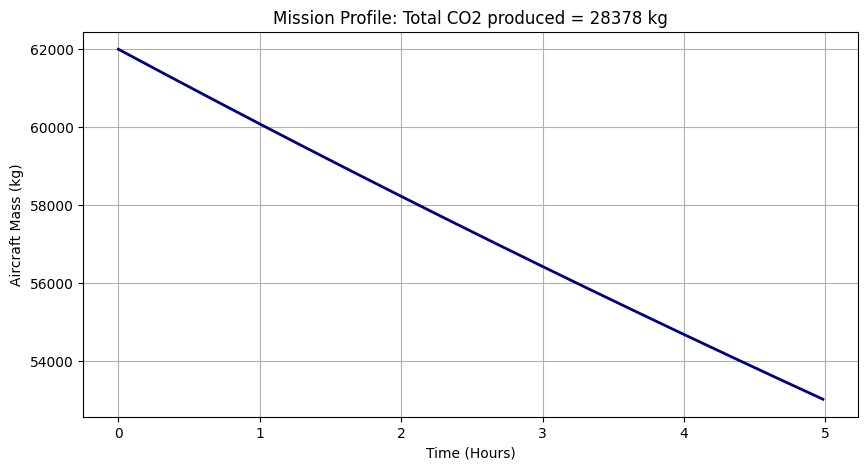

In [2]:
#@title ✈️ Aircraft Sustainability Simulator { run: "auto" }
#@markdown Fill in the parameters below and the graph will update automatically.

import matplotlib.pyplot as plt
import numpy as np

#@markdown ### Mission Parameters
Initial_Mass = 62000 #@param {type:"slider", min:10000, max:100000, step:1000}
L_over_D = 18 #@param {type:"number"}
SAF_Percent = 1 #@param {type:"slider", min:0, max:1, step:0.1}

# Constants
SFC = 1.6e-5
G = 9.81
CO2_JetA = 3.16
CO2_SAF = 0.63

# Simulation (Euler Method)
dt = 60
time = np.arange(0, 18000, dt)
mass = np.zeros(len(time))
mass[0] = Initial_Mass
total_co2 = 0

for i in range(len(time)-1):
    thrust_req = (mass[i] * G) / L_over_D
    fuel_flow = SFC * thrust_req
    mass[i+1] = mass[i] - (fuel_flow * dt)
    step_co2 = (fuel_flow * dt) * ((SAF_Percent * CO2_SAF) + ((1 - SAF_Percent) * CO2_JetA))
    total_co2 += step_co2

# Visualization
plt.figure(figsize=(10,5))
plt.plot(time/3600, mass, color='navy', linewidth=2)
plt.title(f"Mission Profile: Total CO2 produced = {int(total_co2)} kg")
plt.xlabel("Time (Hours)")
plt.ylabel("Aircraft Mass (kg)")
plt.grid(True)
plt.show()